# Day 2 — PyTorch: Building Neural Networks

## Note 2.1 — Tensors and the Shape Contract

### Learning goal and outcome

**Goal.** Stop treating tensors as "arrays that PyTorch happens to use" and start treating a
tensor's `shape`, `dtype` and `device` as a three-part contract that every layer, every loss
function and every batch either honours or violates.

**Outcome.** By the end of this note you can look at a shape error, name the cause before you
read the traceback, and fix it without guessing. You will also have met the class of bug that
produces *no* error at all — the silent broadcast — and know how to detect it.

### Objectives

By the end of this note you will be able to:

- create tensors, convert to and from NumPy, and explain why deep learning runs in `float32`;
- read a shape as a sentence: which axis is the batch, which is the feature, which is the channel;
- reshape safely, and explain when `view` fails and `reshape` does not;
- state the broadcasting rules and use them deliberately for per-feature standardisation;
- recognise the `(N,)` vs `(N, 1)` broadcast bug that inflates a loss without raising an error;
- reproduce `nn.Linear` by hand with a matrix multiply and verify the result matches;
- explain why classification labels must be `long` for `CrossEntropyLoss`;
- detect and resolve device mismatches across `cpu`, `cuda` and `mps`;
- debug five broken cells by predicting the failure before running them.

### Dataset used

**None — synthetic tensors only.**

This is deliberate. Shape debugging is best learned on tensors you constructed yourself, where
you already know the right answer and the only thing under test is your understanding of the
operation. Real data arrives in Note 2.2.

### Table of contents

1. [The one object everything else is made of](#s1)
2. [Reading a shape like a sentence](#s2)
3. [Reshaping without lying to yourself](#s3)
4. [Broadcasting, and the bug it hides](#s4)
5. [Matrix multiplication is the layer](#s5)
6. [dtype and device discipline](#s6)
7. [A shape-debugging clinic](#s7)
8. [Conclusion](#s8)

**Estimated runtime:** every cell in this note completes in under two seconds. Total execution
time is well under one minute; the time you spend here should be thinking time, not waiting time.

### Environment setup

Run this first. It pins the versions this note was written against and reports which compute
device you have. Everything in Note 2.1 runs comfortably on CPU — the device detection matters
because Section 6 demonstrates a device-mismatch error, and the code needs to know what hardware
is actually present.

In [1]:
# Pinned for reproducibility. Uncomment to install in a fresh environment (Colab / Kaggle).
# !pip install -q torch==2.14.0 numpy==2.4.4 matplotlib==3.10.8

import sys
import numpy as np
import torch

print(f"Python      : {sys.version.split()[0]}")
print(f"torch       : {torch.__version__}")
print(f"numpy       : {np.__version__}")

Python      : 3.13.9
torch       : 2.14.0
numpy       : 2.3.5


In [2]:
def get_device() -> torch.device:
    """Return the best available device: CUDA, then Apple MPS, then CPU."""
    if torch.cuda.is_available():
        return torch.device("cuda")
    if torch.backends.mps.is_available() and torch.backends.mps.is_built():
        return torch.device("mps")
    return torch.device("cpu")


DEVICE = get_device()
print(f"Selected device: {DEVICE}")

if DEVICE.type == "cuda":
    print(f"  GPU          : {torch.cuda.get_device_name(0)}")
    print(f"  VRAM         : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
elif DEVICE.type == "mps":
    print("  Apple Silicon GPU via Metal Performance Shaders")
else:
    print("  Running on CPU. Every cell in this note is sized for that.")

# One seed, set once, used everywhere in this note.
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

Selected device: mps
  Apple Silicon GPU via Metal Performance Shaders


<a id="s1"></a>
## 1. The one object everything else is made of

In Note 1.3 you called `torch.tensor(...)` and moved on, because the goal then was to see a
network train. Now the tensor itself is the subject.

A tensor is a block of numbers in memory plus some metadata describing how to interpret that
block. The three pieces of metadata that will govern the rest of this course are:

| Attribute | Question it answers | Typical failure when wrong |
|---|---|---|
| `shape` | How is the block arranged into axes? | `RuntimeError: mat1 and mat2 shapes cannot be multiplied` |
| `dtype` | What kind of number is each element? | `RuntimeError: expected scalar type Long but found Float` |
| `device` | Which processor's memory holds it? | `RuntimeError: Expected all tensors to be on the same device` |

Almost every error you will hit for the next nine days is one of those three. Learning to
interrogate a tensor is therefore not housekeeping — it is the debugging skill.

In [3]:
def describe(name: str, t: torch.Tensor) -> None:
    """Print the three-part contract for a tensor. Use this constantly."""
    print(f"{name:<12} shape={tuple(t.shape)!s:<16} dtype={str(t.dtype):<16} "
          f"device={str(t.device):<6} ndim={t.ndim}  numel={t.numel()}")


scalar = torch.tensor(3.14)
vector = torch.tensor([1.0, 2.0, 3.0])
matrix = torch.tensor([[1.0, 2.0], [3.0, 4.0], [5.0, 6.0]])
cube   = torch.zeros(2, 3, 4)

In [4]:
scalar

tensor(3.1400)

In [5]:
vector

tensor([1., 2., 3.])

In [6]:
matrix

tensor([[1., 2.],
        [3., 4.],
        [5., 6.]])

In [7]:
cube

tensor([[[0., 0., 0., 0.],
         [0., 0., 0., 0.],
         [0., 0., 0., 0.]],

        [[0., 0., 0., 0.],
         [0., 0., 0., 0.],
         [0., 0., 0., 0.]]])

In [8]:
describe("scalar", scalar)
describe("vector", vector)
describe("matrix", matrix)
describe("cube", cube)

scalar       shape=()               dtype=torch.float32    device=cpu    ndim=0  numel=1
vector       shape=(3,)             dtype=torch.float32    device=cpu    ndim=1  numel=3
matrix       shape=(3, 2)           dtype=torch.float32    device=cpu    ndim=2  numel=6
cube         shape=(2, 3, 4)        dtype=torch.float32    device=cpu    ndim=3  numel=24


Notice that the scalar has `shape=()` — an empty tuple, zero axes. That is not a quirk. Your loss
value is a zero-dimensional tensor, and `loss.backward()` only works on one. When you eventually
see `grad can be implicitly created only for scalar outputs`, this is the reason: something you
expected to be a single number still had axes attached.

The construction helpers you will actually reach for:

In [9]:
np.zeros([2,3])

array([[0., 0., 0.],
       [0., 0., 0.]])

In [10]:
torch.zeros(2, 3)

tensor([[0., 0., 0.],
        [0., 0., 0.]])

In [11]:
print("zeros(2,3):\n", torch.zeros(2, 3))
print("\nones(2,3):\n", torch.ones(2, 3))
print("\narange(6):", torch.arange(6))
print("\nlinspace(0,1,5):", torch.linspace(0, 1, 5))
print("\nrandn(2,3)  — standard normal, the default for weight init experiments:\n",
      torch.randn(2, 3))
print("\nrand(2,3)   — uniform on [0,1):\n", torch.rand(2, 3))
print("\neye(3)      — identity, useful for sanity-checking matmuls:\n", torch.eye(3))

# Shape-matching constructors: 'give me zeros shaped like this other thing'.
template = torch.randn(3, 4)
print("\nzeros_like(template).shape:", tuple(torch.zeros_like(template).shape))

zeros(2,3):
 tensor([[0., 0., 0.],
        [0., 0., 0.]])

ones(2,3):
 tensor([[1., 1., 1.],
        [1., 1., 1.]])

arange(6): tensor([0, 1, 2, 3, 4, 5])

linspace(0,1,5): tensor([0.0000, 0.2500, 0.5000, 0.7500, 1.0000])

randn(2,3)  — standard normal, the default for weight init experiments:
 tensor([[ 0.3367,  0.1288,  0.2345],
        [ 0.2303, -1.1229, -0.1863]])

rand(2,3)   — uniform on [0,1):
 tensor([[0.8694, 0.5677, 0.7411],
        [0.4294, 0.8854, 0.5739]])

eye(3)      — identity, useful for sanity-checking matmuls:
 tensor([[1., 0., 0.],
        [0., 1., 0.],
        [0., 0., 1.]])

zeros_like(template).shape: (3, 4)


### Crossing the NumPy border

Your data will arrive from pandas or scikit-learn as NumPy arrays. The bridge runs both ways, and
one direction has a sharp edge.

In [12]:
arr = np.array([[1.0, 2.0], [3.0, 4.0]], dtype=np.float32)

arr

array([[1., 2.],
       [3., 4.]], dtype=float32)

In [13]:
# from_numpy SHARES memory with the array. Cheap, but mutations propagate.
shared = torch.from_numpy(arr)
shared

tensor([[1., 2.],
        [3., 4.]])

In [14]:
arr[0, 0] = 99.0
arr

array([[99.,  2.],
       [ 3.,  4.]], dtype=float32)

In [15]:
shared

tensor([[99.,  2.],
        [ 3.,  4.]])

In [16]:
print("after mutating the numpy array, the tensor sees it:\n", shared)

after mutating the numpy array, the tensor sees it:
 tensor([[99.,  2.],
        [ 3.,  4.]])


In [17]:
# torch.tensor(...) COPIES. Safer default when you are unsure.
arr2 = np.array([[1.0, 2.0], [3.0, 4.0]], dtype=np.float32)
arr2

array([[1., 2.],
       [3., 4.]], dtype=float32)

In [18]:
copied = torch.tensor(arr2)
copied

tensor([[1., 2.],
        [3., 4.]])

In [19]:
arr2[0, 0] = 99.0
arr2

array([[99.,  2.],
       [ 3.,  4.]], dtype=float32)

In [20]:
copied

tensor([[1., 2.],
        [3., 4.]])

In [21]:
print("\nafter mutating, the copy is unaffected:\n", copied)


after mutating, the copy is unaffected:
 tensor([[1., 2.],
        [3., 4.]])


In [22]:
# Going back to numpy. .numpy() also shares memory, and fails on a tensor
# that requires grad — you must .detach() first.
t = torch.randn(2, 2, requires_grad=True)
t

tensor([[-0.3514, -0.7906],
        [-0.0915,  0.2352]], requires_grad=True)

In [23]:
t.numpy()

RuntimeError: Can't call numpy() on Tensor that requires grad. Use tensor.detach().numpy() instead.

In [25]:
t.detach().numpy()

array([[-0.35144043, -0.7906431 ],
       [-0.09150922,  0.23517996]], dtype=float32)

In [26]:
try:
    t.numpy()
except RuntimeError as e:
    print("\nExpected error:", str(e)[:80])
print("Correct:", t.detach().numpy().shape)


Expected error: Can't call numpy() on Tensor that requires grad. Use tensor.detach().numpy() ins
Correct: (2, 2)


### Why float32 and not float64

NumPy defaults to `float64`. PyTorch defaults to `float32`, and this mismatch is the single most
common surprise when converting a pandas DataFrame.

In [27]:
np_default = np.array([1.0, 2.0, 3.0])          # float64
torch_default = torch.tensor([1.0, 2.0, 3.0])   # float32

In [28]:
np_default

array([1., 2., 3.])

In [29]:
torch_default

tensor([1., 2., 3.])

In [30]:
print("numpy default dtype:", np_default.dtype)
print("torch default dtype:", torch_default.dtype)

numpy default dtype: float64
torch default dtype: torch.float32


In [31]:
converted = torch.from_numpy(np_default)
print("\nfrom_numpy on a float64 array gives:", converted.dtype)


from_numpy on a float64 array gives: torch.float64


In [32]:
converted = torch.tensor(np_default, dtype=torch.float32)

In [33]:
converted

tensor([1., 2., 3.])

In [34]:
# A float32 layer refuses a float64 input.
import torch.nn as nn
layer = nn.Linear(3, 2)

In [35]:
layer

Linear(in_features=3, out_features=2, bias=True)

In [36]:
layer(converted)

tensor([-2.1636,  1.5137], grad_fn=<ViewBackward0>)

In [37]:
try:
    layer(converted)
except RuntimeError as e:
    print("\nExpected error:", str(e)[:110])

print("\nFixed:", layer(converted.float()).shape)


Fixed: torch.Size([2])


Deep learning runs in `float32` because halving the bits per number halves memory traffic and
roughly doubles arithmetic throughput, and the extra precision of `float64` buys nothing: gradient
descent is a noisy, approximate procedure whose errors dwarf the difference between the seventh
and sixteenth significant digit. Day 4 pushes this further, to `float16` and `bfloat16`.

The practical rule, which will save you an hour at some point this week:

> Cast to `float32` at the boundary where NumPy becomes PyTorch, not later.
> `X.astype(np.float32)` on the DataFrame side, once, and the problem never recurs.

**Questions to sit with:**

1. `torch.tensor(3.14)` has `ndim=0` and `torch.tensor([3.14])` has `ndim=1`. Both hold one
   number. Which one can you call `.backward()` on, and why does the distinction exist?
2. `from_numpy` shares memory and `torch.tensor` copies. Name a situation where the sharing is a
   feature, and one where it is a bug waiting to happen.

## 2. Reading a shape like a sentence

A shape is not a list of numbers. It is a sentence describing how your data is laid out, and the
convention is stable enough across the whole field that you can read an unfamiliar codebase from
its shapes alone.

The universal rule: **axis 0 is the batch.** Whatever else changes, the first number is how many
independent examples are stacked together. Every layer in PyTorch assumes this without asking.

| Data type | Shape convention | Read it as |
|---|---|---|
| Tabular | `(N, F)` | N rows, F features per row |
| Image | `(N, C, H, W)` | N images, C channels, H high, W wide |
| Token IDs | `(N, L)` | N sequences, L tokens each |
| Token embeddings | `(N, L, E)` | N sequences, L tokens, E numbers per token |

Note that PyTorch puts **channels before spatial dimensions** — `(N, C, H, W)`, not the
`(N, H, W, C)` you may have seen in TensorFlow or in a raw PIL image. This single difference
causes a large fraction of first-week image bugs. Day 10 revisits it when we cross frameworks.

> **🖼 IMAGE 2.1.1 — the four shape layouts**

<div align="center">

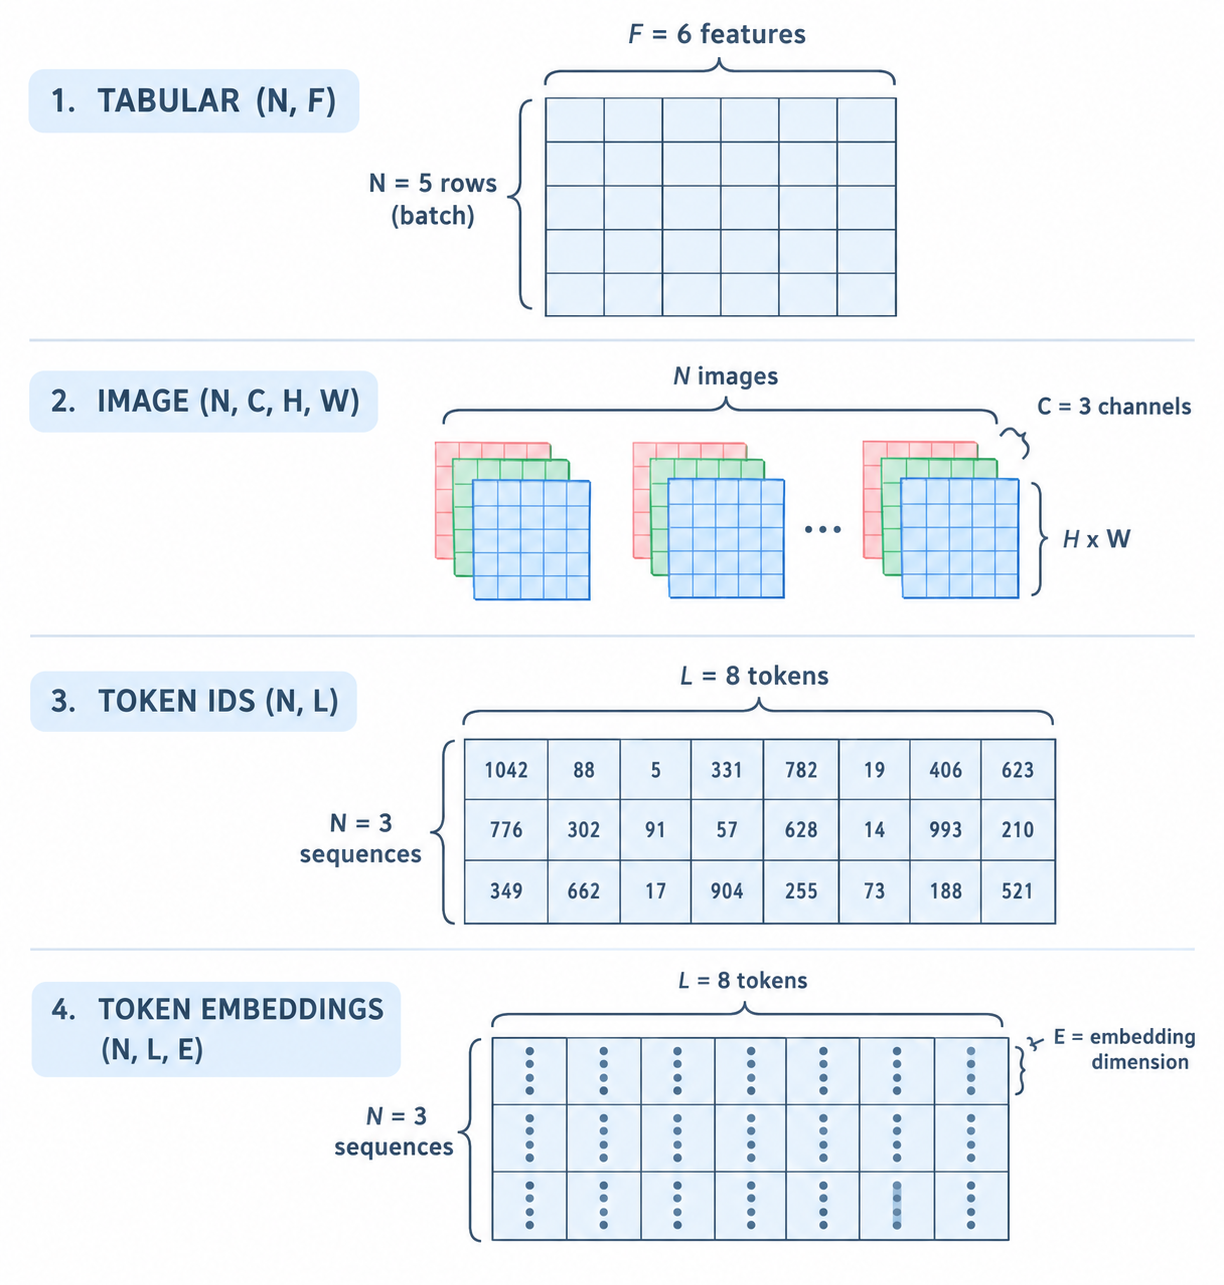


</div>

In [38]:
N, F = 8, 5                     # 8 rows, 5 tabular features
tabular = torch.randn(N, F)

images = torch.randn(4, 3, 32, 32)     # 4 RGB images, 32x32
tokens = torch.randint(0, 1000, (2, 10))       # 2 sequences of 10 token ids
embeds = torch.randn(2, 10, 64)                # same, each token -> 64 numbers

In [39]:
print(images[0][0])

tensor([[-0.5992,  0.4771,  0.7262,  ...,  0.6368,  0.2176, -0.0467],
        [ 1.6192,  1.4506,  0.2695,  ...,  2.0265,  0.9812, -0.6401],
        [-0.8057, -0.2076, -0.9319,  ...,  0.4598,  0.2618, -0.7599],
        ...,
        [ 1.1862, -1.2203,  0.2910,  ..., -2.5380, -0.0334, -1.7017],
        [ 0.3712,  1.5118, -0.8915,  ..., -0.0406,  0.6467, -2.0813],
        [-0.9167, -0.7794, -0.4175,  ...,  3.4456,  0.3673, -0.3919]])


In [40]:
describe("tabular", tabular)
describe("images", images)
describe("tokens", tokens)
describe("embeds", embeds)

print()
print("How many examples in the image batch?  ->", images.shape[0])
print("How many channels per image?           ->", images.shape[1])
print("Pixels per image (H*W)                 ->", images.shape[2] * images.shape[3])
print("Numbers in the whole image batch       ->", images.numel())

tabular      shape=(8, 5)           dtype=torch.float32    device=cpu    ndim=2  numel=40
images       shape=(4, 3, 32, 32)   dtype=torch.float32    device=cpu    ndim=4  numel=12288
tokens       shape=(2, 10)          dtype=torch.int64      device=cpu    ndim=2  numel=20
embeds       shape=(2, 10, 64)      dtype=torch.float32    device=cpu    ndim=3  numel=1280

How many examples in the image batch?  -> 4
How many channels per image?           -> 3
Pixels per image (H*W)                 -> 1024
Numbers in the whole image batch       -> 12288


### Indexing preserves or drops axes, and it matters

The difference between an index and a slice is the difference between losing an axis and keeping
it. This is the origin of a very large share of `(N,)` vs `(N, 1)` confusion.

In [41]:
batch = torch.randn(8, 5)
batch

tensor([[-0.2514,  1.6124,  0.0593, -0.2723, -0.1372],
        [ 0.7022,  1.5885,  1.0206, -1.0839,  1.0406],
        [-1.2676,  1.3164,  0.0458, -0.1287, -2.0694],
        [ 0.4159,  0.6327,  1.3299, -0.2185, -1.3713],
        [-0.8273,  0.9662, -0.5898, -0.8523, -0.1236],
        [-1.2720, -1.0702,  0.0196,  0.4001, -0.2221],
        [ 0.1648, -0.2799,  0.7053,  0.4979,  1.1845],
        [ 0.4461, -0.2101,  0.4610, -0.4705,  2.3401]])

In [42]:
describe("batch", batch)

batch        shape=(8, 5)           dtype=torch.float32    device=cpu    ndim=2  numel=40


In [43]:
batch[0]

tensor([-0.2514,  1.6124,  0.0593, -0.2723, -0.1372])

In [44]:
describe("batch[0]", batch[0])        # integer index -> axis 0 disappears

batch[0]     shape=(5,)             dtype=torch.float32    device=cpu    ndim=1  numel=5


In [45]:
batch[0:1]

tensor([[-0.2514,  1.6124,  0.0593, -0.2723, -0.1372]])

In [46]:
describe("batch[0:1]", batch[0:1])    # slice        -> axis 0 survives with length 1

batch[0:1]   shape=(1, 5)           dtype=torch.float32    device=cpu    ndim=2  numel=5


In [47]:
batch[:, 2]

tensor([ 0.0593,  1.0206,  0.0458,  1.3299, -0.5898,  0.0196,  0.7053,  0.4610])

In [48]:
describe("batch[:, 2]", batch[:, 2])  # one feature, as a flat vector

batch[:, 2]  shape=(8,)             dtype=torch.float32    device=cpu    ndim=1  numel=8


In [49]:
batch[:, 2:3]

tensor([[ 0.0593],
        [ 1.0206],
        [ 0.0458],
        [ 1.3299],
        [-0.5898],
        [ 0.0196],
        [ 0.7053],
        [ 0.4610]])

In [50]:
describe("batch[:, 2:3]", batch[:, 2:3])  # one feature, as a column

batch[:, 2:3] shape=(8, 1)           dtype=torch.float32    device=cpu    ndim=2  numel=8


In [51]:
print()
print("A single example fed to a model must still look like a batch of one.")
print("batch[0].shape    =", tuple(batch[0].shape), " <- a model will reject or misread this")
print("batch[0:1].shape  =", tuple(batch[0:1].shape), " <- correct: batch of 1")


A single example fed to a model must still look like a batch of one.
batch[0].shape    = (5,)  <- a model will reject or misread this
batch[0:1].shape  = (1, 5)  <- correct: batch of 1


In [52]:
batch

tensor([[-0.2514,  1.6124,  0.0593, -0.2723, -0.1372],
        [ 0.7022,  1.5885,  1.0206, -1.0839,  1.0406],
        [-1.2676,  1.3164,  0.0458, -0.1287, -2.0694],
        [ 0.4159,  0.6327,  1.3299, -0.2185, -1.3713],
        [-0.8273,  0.9662, -0.5898, -0.8523, -0.1236],
        [-1.2720, -1.0702,  0.0196,  0.4001, -0.2221],
        [ 0.1648, -0.2799,  0.7053,  0.4979,  1.1845],
        [ 0.4461, -0.2101,  0.4610, -0.4705,  2.3401]])

In [53]:
batch.shape

torch.Size([8, 5])

In [54]:
batch[0]

tensor([-0.2514,  1.6124,  0.0593, -0.2723, -0.1372])

In [55]:
batch[0].shape

torch.Size([5])

In [56]:
batch[0:1]

tensor([[-0.2514,  1.6124,  0.0593, -0.2723, -0.1372]])

In [57]:
batch[0:1].shape

torch.Size([1, 5])

When you deploy a model and pass it one customer record, this is the bug you will hit. The model
was trained on `(N, F)`; you hand it `(F,)`; `nn.Linear` happens to accept it and returns
something plausible-looking. Section 4 shows what happens next.

**Questions to sit with:**

1. Given `images` with shape `(4, 3, 32, 32)`, what does `images[1, 0]` return, and what shape is
   it? Predict before you run it.
2. Your model's output has shape `(32, 1)` and your labels have shape `(32,)`. Which one should
   change, and does the answer depend on the loss function you chose?

## 3. Reshaping without lying to yourself

Reshaping does not move data. It rewrites the metadata that says how to walk through the block of
memory. That is why it is nearly free — and why it occasionally refuses.

The number of elements must be conserved: a `(4, 3, 32, 32)` tensor has 12,288 elements, so it can
become `(4, 3072)` or `(12, 1024)` or `(12288,)`, but never `(4, 3000)`.

In [58]:
x = torch.arange(24)
x

tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
        18, 19, 20, 21, 22, 23])

In [59]:
describe("x", x)

x            shape=(24,)            dtype=torch.int64      device=cpu    ndim=1  numel=24


In [60]:
x.view(4, 6)

tensor([[ 0,  1,  2,  3,  4,  5],
        [ 6,  7,  8,  9, 10, 11],
        [12, 13, 14, 15, 16, 17],
        [18, 19, 20, 21, 22, 23]])

In [61]:
describe("x.view(4, 6)", x.view(4, 6))
describe("x.view(2, 3, 4)", x.view(2, 3, 4))
describe("x.view(4, -1)", x.view(4, -1))     # -1 means 'infer this axis'
describe("x.view(-1, 8)", x.view(-1, 8))

x.view(4, 6) shape=(4, 6)           dtype=torch.int64      device=cpu    ndim=2  numel=24
x.view(2, 3, 4) shape=(2, 3, 4)        dtype=torch.int64      device=cpu    ndim=3  numel=24
x.view(4, -1) shape=(4, 6)           dtype=torch.int64      device=cpu    ndim=2  numel=24
x.view(-1, 8) shape=(3, 8)           dtype=torch.int64      device=cpu    ndim=2  numel=24


In [62]:
x.view(5, 5)

RuntimeError: shape '[5, 5]' is invalid for input of size 24

In [63]:
# Conservation is enforced.
try:
    x.view(5, 5)
except RuntimeError as e:
    print("\nExpected error:", str(e)[:70])


Expected error: shape '[5, 5]' is invalid for input of size 24


### Where `view` fails and `reshape` succeeds

A tensor is *contiguous* when its elements sit in memory in the same order you would read them by
walking the axes left to right. Operations like `.t()` and `.permute()` do not move data — they
just relabel the axes — so the result is a view onto memory that is no longer in reading order.

`view` requires contiguity, because it only rewrites strides. `reshape` will silently copy if it
has to. That copy is the entire difference, and it is why `reshape` is the safer default.

In [64]:
torch.arange(12)

tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11])

In [65]:
x = torch.arange(12).reshape(3, 4)
x

tensor([[ 0,  1,  2,  3],
        [ 4,  5,  6,  7],
        [ 8,  9, 10, 11]])

In [66]:
x.view(12)

tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11])

In [67]:
xt = x.t()      # transpose: a view, no data moved

In [68]:
xt

tensor([[ 0,  4,  8],
        [ 1,  5,  9],
        [ 2,  6, 10],
        [ 3,  7, 11]])

In [69]:
print("x contiguous? ", x.is_contiguous())
print("x.t() contiguous? ", xt.is_contiguous())

x contiguous?  True
x.t() contiguous?  False


In [70]:
xt.view(12)

RuntimeError: view size is not compatible with input tensor's size and stride (at least one dimension spans across two contiguous subspaces). Use .reshape(...) instead.

In [71]:
xt.reshape(12)

tensor([ 0,  4,  8,  1,  5,  9,  2,  6, 10,  3,  7, 11])

In [72]:
try:
    xt.view(12)
except RuntimeError as e:
    print("\nview on a non-contiguous tensor fails:")
    print(" ", str(e)[:95], "...")


view on a non-contiguous tensor fails:
  view size is not compatible with input tensor's size and stride (at least one dimension spans a ...


In [73]:
print("\nreshape handles it by copying:", xt.reshape(12))
print("or make it explicit:            ", xt.contiguous().view(12))


reshape handles it by copying: tensor([ 0,  4,  8,  1,  5,  9,  2,  6, 10,  3,  7, 11])
or make it explicit:             tensor([ 0,  4,  8,  1,  5,  9,  2,  6, 10,  3,  7, 11])


### Adding and removing length-1 axes

`unsqueeze` inserts an axis of length 1 at a position; `squeeze` removes axes of length 1. You
will use these constantly to reconcile a model output with a loss function's expectations.

In [74]:
v = torch.tensor([1.0, 2.0, 3.0])
v

tensor([1., 2., 3.])

In [75]:
describe("v", v)

v            shape=(3,)             dtype=torch.float32    device=cpu    ndim=1  numel=3


In [76]:
v.unsqueeze(0)

tensor([[1., 2., 3.]])

In [77]:
describe("v.unsqueeze(0)", v.unsqueeze(0))    # (3,) -> (1, 3): a batch of one row

v.unsqueeze(0) shape=(1, 3)           dtype=torch.float32    device=cpu    ndim=2  numel=3


In [78]:
v.unsqueeze(1)

tensor([[1.],
        [2.],
        [3.]])

In [79]:
describe("v.unsqueeze(1)", v.unsqueeze(1))    # (3,) -> (3, 1): a column

v.unsqueeze(1) shape=(3, 1)           dtype=torch.float32    device=cpu    ndim=2  numel=3


In [80]:
col = v.unsqueeze(1)
describe("col.squeeze(1)", col.squeeze(1))    # back to (3,)

col.squeeze(1) shape=(3,)             dtype=torch.float32    device=cpu    ndim=1  numel=3


In [81]:
# squeeze() with no argument removes EVERY length-1 axis. Convenient and dangerous:
# if your batch size happens to be 1, it silently removes the batch axis too.
risky = torch.randn(1, 1, 5)
print()
describe("risky", risky)
describe("risky.squeeze()", risky.squeeze())        # lost both axes
describe("risky.squeeze(1)", risky.squeeze(1))      # only the one you meant


risky        shape=(1, 1, 5)        dtype=torch.float32    device=cpu    ndim=3  numel=5
risky.squeeze() shape=(5,)             dtype=torch.float32    device=cpu    ndim=1  numel=5
risky.squeeze(1) shape=(1, 5)           dtype=torch.float32    device=cpu    ndim=2  numel=5


That last pair is a real production bug. A batch of one — the last incomplete batch of an epoch,
or a single request in a deployed service — turns `squeeze()` into something that removes the
batch axis. Always name the axis: `squeeze(1)`, never bare `squeeze()`.

### Reordering axes: `permute` and `transpose`

In [82]:
img = torch.randn(4, 32, 32, 3)     # what PIL / matplotlib hand you: (N, H, W, C)
describe("as loaded (N,H,W,C)", img)
img

as loaded (N,H,W,C) shape=(4, 32, 32, 3)   dtype=torch.float32    device=cpu    ndim=4  numel=12288


tensor([[[[-1.1421,  0.4946,  2.1283],
          [-0.0648, -1.2929,  0.8945],
          [ 0.6557, -0.1357, -0.4208],
          ...,
          [-0.7476,  0.3930, -2.1820],
          [ 0.2457,  0.6763, -0.2301],
          [-0.1118,  1.3171, -1.7199]],

         [[ 1.1735,  1.5073, -1.3217],
          [ 0.2432, -0.9750,  0.0355],
          [ 0.4600,  0.5497,  2.2624],
          ...,
          [ 0.0354, -0.5816, -0.1224],
          [ 0.8810, -1.0891, -0.5495],
          [ 1.2374, -1.3882,  0.2245]],

         [[-0.6972, -1.0185,  0.8052],
          [-0.3137, -1.6625,  0.9508],
          [-0.3532, -2.7029, -0.6655],
          ...,
          [-0.0577,  0.4384, -0.1732],
          [ 1.4584, -0.8294, -0.1922],
          [-0.4082,  1.1487, -1.9976]],

         ...,

         [[ 0.3614, -0.4734, -1.5011],
          [ 1.7683, -0.7381, -2.0535],
          [-2.1331,  1.7796, -0.4305],
          ...,
          [ 0.7945,  0.5995,  3.6199],
          [-1.3311,  0.4711, -0.4444],
          [ 2.6325, -0

In [83]:
torch_layout = img.permute(0, 3, 1, 2)      # -> (N, C, H, W)
describe("permuted (N,C,H,W)", torch_layout)
torch_layout

permuted (N,C,H,W) shape=(4, 3, 32, 32)   dtype=torch.float32    device=cpu    ndim=4  numel=12288


tensor([[[[-1.1421, -0.0648,  0.6557,  ..., -0.7476,  0.2457, -0.1118],
          [ 1.1735,  0.2432,  0.4600,  ...,  0.0354,  0.8810,  1.2374],
          [-0.6972, -0.3137, -0.3532,  ..., -0.0577,  1.4584, -0.4082],
          ...,
          [ 0.3614,  1.7683, -2.1331,  ...,  0.7945, -1.3311,  2.6325],
          [ 0.7385, -0.4573, -0.6366,  ..., -1.9237,  0.1576,  0.7428],
          [ 0.8351,  0.1420,  0.6872,  ...,  0.7442, -0.6288, -0.6563]],

         [[ 0.4946, -1.2929, -0.1357,  ...,  0.3930,  0.6763,  1.3171],
          [ 1.5073, -0.9750,  0.5497,  ..., -0.5816, -1.0891, -1.3882],
          [-1.0185, -1.6625, -2.7029,  ...,  0.4384, -0.8294,  1.1487],
          ...,
          [-0.4734, -0.7381,  1.7796,  ...,  0.5995,  0.4711, -0.9324],
          [-0.5175, -0.5778, -0.8230,  ..., -0.3312, -1.2471, -0.5087],
          [ 1.5808, -0.7683,  0.0364,  ...,  0.9471, -0.3980,  0.7662]],

         [[ 2.1283,  0.8945, -0.4208,  ..., -2.1820, -0.2301, -1.7199],
          [-1.3217,  0.0355,  

In [84]:
print("contiguous after permute?", torch_layout.is_contiguous())

contiguous after permute? False


In [85]:
# transpose swaps exactly two axes; permute reorders all of them.
seq = torch.randn(2, 10, 64)        # (N, L, E)
describe("seq", seq)
seq

seq          shape=(2, 10, 64)      dtype=torch.float32    device=cpu    ndim=3  numel=1280


tensor([[[-2.5744e-01,  8.3295e-04,  2.0257e-01,  ..., -2.6973e-01,
          -4.1540e-01,  4.1612e-01],
         [ 1.6719e+00,  9.3445e-01,  9.3036e-01,  ..., -3.7335e-01,
           2.9129e-01, -1.4553e+00],
         [ 6.7020e-01,  2.0534e-01, -4.4031e-01,  ...,  9.1655e-01,
          -1.0710e+00, -9.0602e-01],
         ...,
         [ 1.4881e-01, -1.0629e+00, -3.5009e-01,  ...,  1.4352e+00,
          -1.1908e+00,  7.3657e-01],
         [ 2.5693e+00,  3.2579e-01, -1.2760e-01,  ..., -2.6638e-01,
          -9.7265e-01,  1.1840e+00],
         [ 4.5051e-01, -2.4164e+00, -1.3880e-01,  ..., -1.5625e+00,
           1.6677e+00,  2.3402e+00]],

        [[ 9.5596e-01,  3.6468e-01,  4.1431e-01,  ..., -3.4242e-01,
           2.0233e-01, -1.7589e+00],
         [ 5.5581e-01, -7.1602e-01, -1.5441e+00,  ..., -6.4152e-01,
          -5.7506e-02,  1.3140e+00],
         [-1.1513e-01,  1.4627e-01,  1.8633e+00,  ...,  7.4607e-01,
           1.4400e+00,  1.6266e+00],
         ...,
         [-1.3137e+00,  7

In [86]:
describe("seq.transpose(1, 2)", seq.transpose(1, 2))   # (N, E, L)

seq.transpose(1, 2) shape=(2, 64, 10)      dtype=torch.float32    device=cpu    ndim=3  numel=1280


`permute` names the new order of *all* axes; `transpose` swaps a specific pair. Neither moves
data, so both leave you non-contiguous — call `.contiguous()` if a later `view` complains.

**Questions to sit with:**

1. `x.view(4, -1)` and `x.reshape(4, -1)` return the same values here. Under what circumstance do
   they differ in cost, and how would you detect that in your own code?
2. You load a batch of images and get shape `(16, 224, 224, 3)`. Write the one-line fix. Now
   explain what your model would have computed if you had passed it unfixed and PyTorch had not
   raised an error.

## 4. Broadcasting, and the bug it hides

Broadcasting lets PyTorch combine tensors of different shapes by virtually stretching length-1
axes. It is what makes per-feature standardisation a one-liner. It is also the mechanism behind
the worst category of deep learning bug: the one that runs.

**The rule.** Align shapes from the right. For each axis pair, they are compatible if they are
equal, or if one of them is 1. A missing axis on the left counts as 1.

```
   (8, 5)        (8, 5)        (8, 5)         (8, 5)
   (   5)   OK   (8, 1)   OK   (1, 5)   OK    (   8)   FAILS
-> (8, 5)     -> (8, 5)     -> (8, 5)         5 vs 8, neither is 1
```

> **🖼 IMAGE 2.1.2 — broadcasting alignment**

<div align="center">

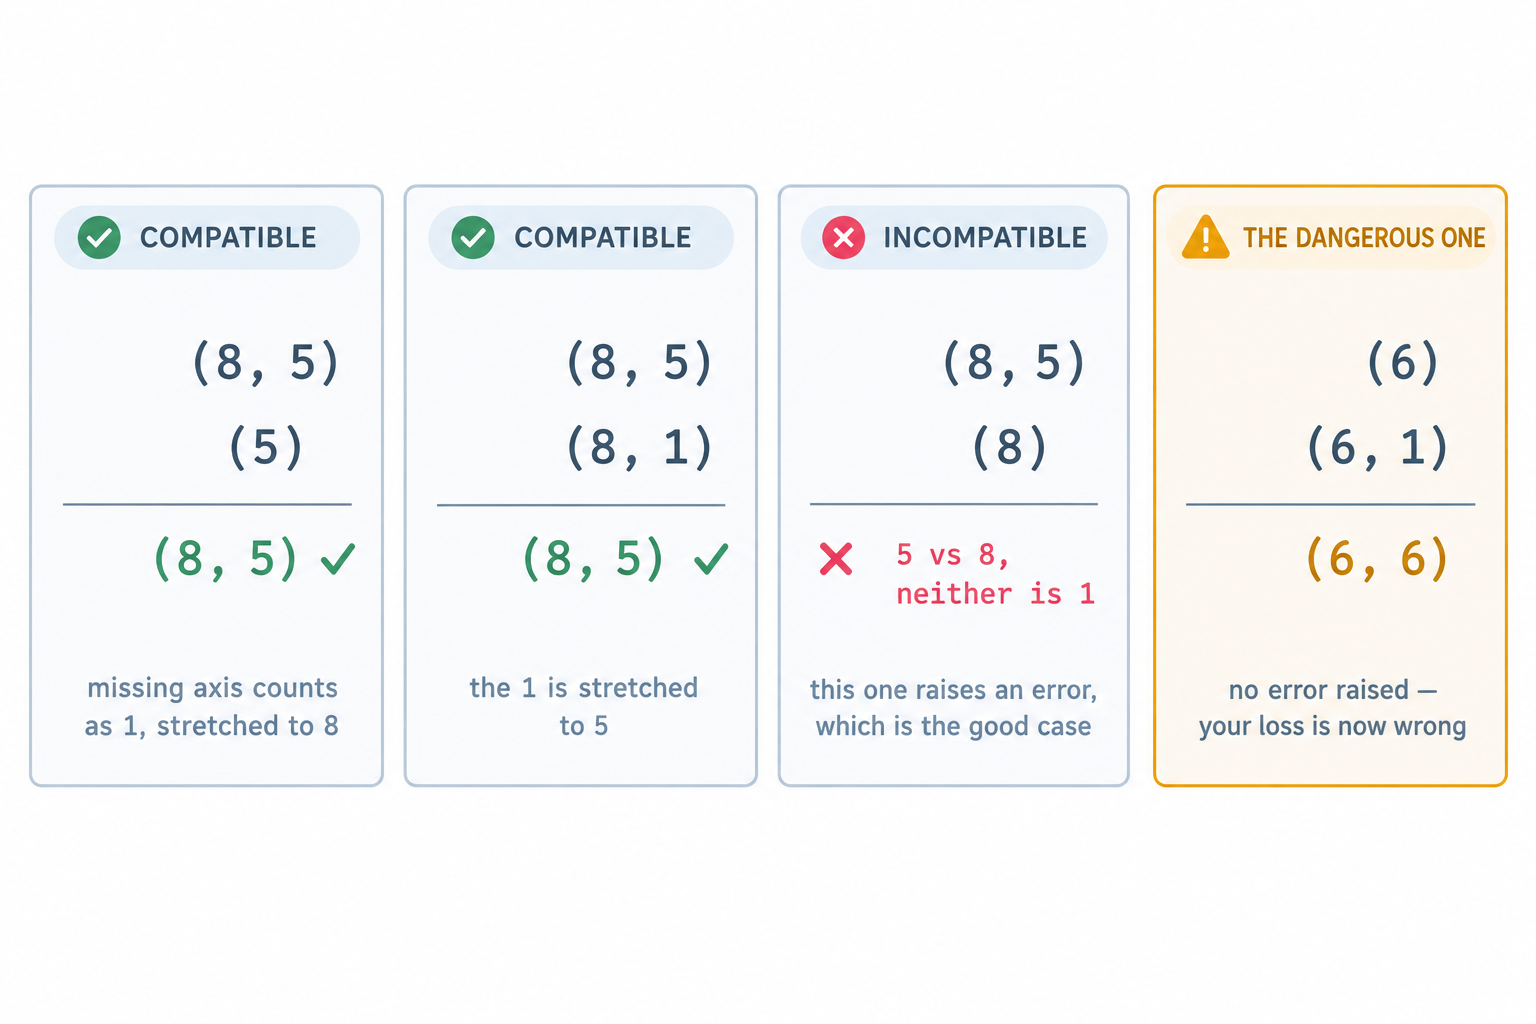


</div>

In [87]:
batch = torch.arange(40, dtype=torch.float32).reshape(8, 5)
batch

tensor([[ 0.,  1.,  2.,  3.,  4.],
        [ 5.,  6.,  7.,  8.,  9.],
        [10., 11., 12., 13., 14.],
        [15., 16., 17., 18., 19.],
        [20., 21., 22., 23., 24.],
        [25., 26., 27., 28., 29.],
        [30., 31., 32., 33., 34.],
        [35., 36., 37., 38., 39.]])

In [88]:
per_feature = torch.tensor([0., 10., 100., 1000., 10000.])   # (5,)
per_feature

tensor([    0.,    10.,   100.,  1000., 10000.])

In [89]:
print("(8,5) + (5,)   ->", tuple((batch + per_feature).shape), " broadcast across rows")

(8,5) + (5,)   -> (8, 5)  broadcast across rows


In [90]:
batch + per_feature

tensor([[0.0000e+00, 1.1000e+01, 1.0200e+02, 1.0030e+03, 1.0004e+04],
        [5.0000e+00, 1.6000e+01, 1.0700e+02, 1.0080e+03, 1.0009e+04],
        [1.0000e+01, 2.1000e+01, 1.1200e+02, 1.0130e+03, 1.0014e+04],
        [1.5000e+01, 2.6000e+01, 1.1700e+02, 1.0180e+03, 1.0019e+04],
        [2.0000e+01, 3.1000e+01, 1.2200e+02, 1.0230e+03, 1.0024e+04],
        [2.5000e+01, 3.6000e+01, 1.2700e+02, 1.0280e+03, 1.0029e+04],
        [3.0000e+01, 4.1000e+01, 1.3200e+02, 1.0330e+03, 1.0034e+04],
        [3.5000e+01, 4.6000e+01, 1.3700e+02, 1.0380e+03, 1.0039e+04]])

In [91]:
per_row = torch.arange(8, dtype=torch.float32).unsqueeze(1)  # (8,1)
print("(8,5) + (8,1)  ->", tuple((batch + per_row).shape), " broadcast across columns")

bad = torch.arange(8, dtype=torch.float32)                   # (8,)
try:
    batch + bad
except RuntimeError as e:
    print("\n(8,5) + (8,)   -> error, which is exactly what you want:")
    print("  ", str(e)[:100])

(8,5) + (8,1)  -> (8, 5)  broadcast across columns

(8,5) + (8,)   -> error, which is exactly what you want:
   The size of tensor a (5) must match the size of tensor b (8) at non-singleton dimension 1


### Using it on purpose: per-feature standardisation

This is the operation you will perform on every tabular dataset for the rest of the course, and
broadcasting is what makes it two lines instead of a loop.

In [92]:
X = torch.randn(200, 4) * torch.tensor([1.0, 50.0, 0.01, 300.0]) + torch.tensor([0., 100., 5., -20.])

print("Before standardisation")
print("  mean per feature:", X.mean(dim=0).numpy().round(3))
print("  std  per feature:", X.std(dim=0).numpy().round(3))

mu = X.mean(dim=0)            # (4,)  -- collapse the batch axis
sd = X.std(dim=0)             # (4,)
X_std = (X - mu) / sd         # (200,4) - (4,) broadcasts across all 200 rows

print("\nAfter standardisation")
print("  mean per feature:", X_std.mean(dim=0).numpy().round(6))
print("  std  per feature:", X_std.std(dim=0).numpy().round(6))

Before standardisation
  mean per feature: [  0.178 104.835   5.001 -30.663]
  std  per feature: [1.05200e+00 5.04490e+01 1.00000e-02 2.74218e+02]

After standardisation
  mean per feature: [ 0.0e+00 -0.0e+00  2.3e-05 -0.0e+00]
  std  per feature: [1. 1. 1. 1.]


Note `dim=0`. Reducing along axis 0 collapses the batch and leaves one statistic *per feature* —
which is what standardisation means. Reducing along `dim=1` would collapse the features and give
one statistic per row, which is meaningless here. Getting this backwards produces a tensor of
plausible shape and no error.

### The silent broadcast

Here is the bug. Your model outputs `(N,)` and your labels are `(N, 1)` — or the reverse. Neither
shape is wrong on its own. Together they broadcast to `(N, N)`, and the loss function dutifully
averages over an `N x N` matrix of every prediction compared against every label.

In [93]:
import torch.nn.functional as Fn
import warnings

targets = torch.tensor([[1.0], [3.0], [5.0], [7.0], [9.0], [11.0]])   # (6, 1)
preds   = targets.squeeze(1) + 0.05 * torch.randn(6)                  # (6,)  -- nearly perfect

describe("preds", preds)
describe("targets", targets)

correct = Fn.mse_loss(preds, targets.squeeze(1))

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    broadcast = Fn.mse_loss(preds, targets)

print(f"\nShape of (preds - targets): {tuple((preds - targets).shape)}   <- the tell")
print(f"Correct loss   : {correct.item():.6f}")
print(f"Broadcast loss : {broadcast.item():.6f}")
print(f"Ratio          : {broadcast.item() / correct.item():.0f}x too large")

preds        shape=(6,)             dtype=torch.float32    device=cpu    ndim=1  numel=6
targets      shape=(6, 1)           dtype=torch.float32    device=cpu    ndim=2  numel=6

Shape of (preds - targets): (6, 6)   <- the tell
Correct loss   : 0.001768
Broadcast loss : 23.243324
Ratio          : 13147x too large


The predictions sit within about 0.05 of the targets. The correct loss is roughly 0.0018. The
broadcast loss is over 23 — four orders of magnitude larger — and your training run will look like
a model that refuses to learn, when in fact it learned fine and you measured it wrong.

PyTorch does emit a `UserWarning` here, which we suppressed to show the number. In a real run that
warning scrolls past in the first epoch and is never seen again. Do not rely on it.

And do not assume the guard is uniform. As of torch 2.14 the binary cross-entropy losses were
hardened to raise on a shape mismatch, while the regression losses still broadcast with only a
warning. Run the cell below to see where the line currently sits on *your* version — the answer
is a property of the release you installed, not a law.

**The defence** is an assertion, written once, at the top of your training loop:

In [94]:
def check_loss_shapes(preds: torch.Tensor, targets: torch.Tensor) -> None:
    """Fail loudly at step 1 instead of quietly for 50 epochs."""
    if preds.shape != targets.shape:
        raise ValueError(
            f"Shape mismatch: preds {tuple(preds.shape)} vs targets {tuple(targets.shape)}. "
            f"These will broadcast to {tuple(torch.broadcast_shapes(preds.shape, targets.shape))}."
        )


try:
    check_loss_shapes(preds, targets)
except ValueError as e:
    print("Caught before it cost you an afternoon:\n ", e)

check_loss_shapes(preds, targets.squeeze(1))
print("\nMatching shapes pass silently.")

Caught before it cost you an afternoon:
  Shape mismatch: preds (6,) vs targets (6, 1). These will broadcast to (6, 6).

Matching shapes pass silently.


In [95]:
# Which losses protect you, and which do not? Check, do not assume.
import warnings

p = torch.randn(6, 1)
t_reg = torch.randn(6)
t_bin = torch.randint(0, 2, (6,)).float()

losses = [
    ("MSELoss", nn.MSELoss(), t_reg),
    ("L1Loss", nn.L1Loss(), t_reg),
    ("SmoothL1Loss", nn.SmoothL1Loss(), t_reg),
    ("BCEWithLogitsLoss", nn.BCEWithLogitsLoss(), t_bin),
]

print(f"Feeding preds {tuple(p.shape)} against targets of shape (6,)\n")
for name, fn, target in losses:
    try:
        with warnings.catch_warnings(record=True) as caught:
            warnings.simplefilter("always")
            value = fn(p, target)
        flag = "warned" if caught else "SILENT"
        print(f"  {name:<20} ran, loss={value.item():8.4f}   ({flag})")
    except (ValueError, RuntimeError) as e:
        print(f"  {name:<20} raised {type(e).__name__}  <- protected")

Feeding preds (6, 1) against targets of shape (6,)

  MSELoss              ran, loss=  3.3967   (warned)
  L1Loss               ran, loss=  1.5244   (warned)
  SmoothL1Loss         ran, loss=  1.0952   (warned)
  BCEWithLogitsLoss    raised ValueError  <- protected


The regression losses run. The binary loss refuses. There is no principle behind that split — it
is the accumulated history of which bug reports got acted on. Which is the argument for
`check_loss_shapes`: your own assertion behaves the same way on every loss and every version.

**Questions to sit with:**

1. `nn.MSELoss` on a batch of 256 with a model that outputs `(256, 1)` and targets of shape
   `(256,)`. What matrix does the loss actually average over, and how many entries does it have?
   Roughly what fraction of those entries compare a prediction to *its own* target?
2. You standardise using `X.mean(dim=1, keepdim=True)` by mistake. The code runs. Describe, in
   terms of what each row now represents, what your model is being asked to learn.

## 5. Matrix multiplication is the layer

In Note 1.2 you multiplied nine parameters by hand. `nn.Linear` is that operation at scale, and
nothing more. Proving this to yourself removes the last of the magic from the phrase "dense layer".

The shape rule for `A @ B`: the inner dimensions must match, and the outer ones survive.

```
(N, in) @ (in, out) -> (N, out)
     ^______^  must match
  ^                ^  these survive
```

In [96]:
A = torch.randn(8, 5)
B = torch.randn(5, 3)

In [97]:
A

tensor([[ 8.8873e-01,  5.1824e-01,  4.7037e-01, -7.1866e-01,  1.2050e+00],
        [-1.3539e-01, -2.8148e-01, -3.0537e-01, -1.9027e+00, -3.0323e-01],
        [ 3.7933e-01,  1.5163e-01,  4.0593e-01, -4.0637e-01,  7.4333e-05],
        [ 8.6651e-01, -5.2250e-01,  9.1628e-01, -1.9131e-01,  2.3943e+00],
        [-2.7164e-01, -1.3006e+00,  6.2479e-01,  1.5261e+00, -3.8543e-01],
        [-5.5999e-01,  2.9853e-01,  2.5498e-01,  1.9409e+00, -1.1855e-01],
        [ 4.2360e-01, -4.4879e-01,  8.2307e-01,  8.9556e-01, -7.8797e-01],
        [-1.1197e-01, -1.0768e-01,  5.4267e-01,  1.6382e+00, -4.6443e-01]])

In [98]:
A.shape

torch.Size([8, 5])

In [99]:
B

tensor([[-1.0112,  0.0038,  1.3225],
        [ 0.2166, -0.7708,  1.3247],
        [ 0.2447,  0.6156, -0.9525],
        [-0.0114,  1.0010, -0.4248],
        [ 0.9434,  1.2993, -0.1211]])

In [100]:
B.shape

torch.Size([5, 3])

In [101]:
A@B

tensor([[ 0.4737,  0.7398,  1.5732],
        [-0.2632, -2.2702,  0.5839],
        [-0.2467, -0.2722,  0.4885],
        [ 1.4959,  3.8897, -0.6277],
        [-0.2352,  2.4129, -3.2789],
        [ 0.5593,  1.7137, -1.3982],
        [-1.0778,  0.7269, -1.1033],
        [-0.2341,  1.4531, -1.4473]])

In [102]:
(A@B).shape

torch.Size([8, 3])

In [103]:
print("A @ B ->", tuple((A @ B).shape))

try:
    B @ A
except RuntimeError as e:
    print("\nB @ A fails, as it must:", str(e)[:80])

# Element-wise multiply is a completely different operation. Do not confuse * with @.
C_ = torch.randn(8, 5)
print("\nA * C_ (element-wise) ->", tuple((A * C_).shape))
print("A @ B  (matrix)       ->", tuple((A @ B).shape))

A @ B -> (8, 3)

B @ A fails, as it must: mat1 and mat2 shapes cannot be multiplied (5x3 and 8x5)

A * C_ (element-wise) -> (8, 5)
A @ B  (matrix)       -> (8, 3)


### Rebuilding `nn.Linear` by hand

PyTorch stores a linear layer's weight with shape `(out_features, in_features)` — transposed
relative to the multiply. That ordering is a memory-layout decision, and it is why you see
`x @ W.T` rather than `x @ W`.

In [104]:
import torch.nn as nn

torch.manual_seed(SEED)
layer = nn.Linear(in_features=5, out_features=3)

describe("layer.weight", layer.weight)
describe("layer.bias", layer.bias)

x = torch.randn(8, 5)

official = layer(x)
manual = x @ layer.weight.T + layer.bias     # (8,5) @ (5,3) -> (8,3), then + (3,) broadcasts

describe("official", official)
describe("manual", manual)

print("\nMax absolute difference:", (official - manual).abs().max().item())
print("Identical within float32 tolerance:", torch.allclose(official, manual, atol=1e-6))

layer.weight shape=(3, 5)           dtype=torch.float32    device=cpu    ndim=2  numel=15
layer.bias   shape=(3,)             dtype=torch.float32    device=cpu    ndim=1  numel=3
official     shape=(8, 3)           dtype=torch.float32    device=cpu    ndim=2  numel=24
manual       shape=(8, 3)           dtype=torch.float32    device=cpu    ndim=2  numel=24

Max absolute difference: 0.0
Identical within float32 tolerance: True


Zero difference, or near enough that only floating-point ordering separates them. `nn.Linear` is
`x @ W.T + b`. Everything else the class provides — parameter registration, device movement,
gradient tracking — is bookkeeping around that one line.

This is worth pausing on, because it collapses the whole of Section 5 into a single sentence you
can carry: **a layer is a matrix multiply that reshapes the last axis from `in_features` to
`out_features`, and leaves every other axis untouched.**

That last clause matters more than it looks:

In [105]:
# nn.Linear operates on the LAST axis only. Every leading axis is treated as batch.
proj = nn.Linear(64, 16)

flat  = torch.randn(32, 64)          # (N, E)      tabular-style
seq   = torch.randn(4, 10, 64)       # (N, L, E)   transformer-style
deep  = torch.randn(2, 3, 5, 64)     # arbitrary leading axes

describe("flat -> ", proj(flat))
describe("seq  -> ", proj(seq))
describe("deep -> ", proj(deep))

print("\nThe layer never asked how many leading axes there were.")
print("This is exactly why the same nn.Linear works inside a Transformer on Day 6.")

flat ->      shape=(32, 16)         dtype=torch.float32    device=cpu    ndim=2  numel=512
seq  ->      shape=(4, 10, 16)      dtype=torch.float32    device=cpu    ndim=3  numel=640
deep ->      shape=(2, 3, 5, 16)    dtype=torch.float32    device=cpu    ndim=4  numel=480

The layer never asked how many leading axes there were.
This is exactly why the same nn.Linear works inside a Transformer on Day 6.


### Counting parameters

Parameter count is the first number anyone asks about a model. It is fully determined by the
shapes.

In [106]:
model = nn.Sequential(
    nn.Linear(50, 64),
    nn.ReLU(),
    nn.Linear(64, 32),
    nn.ReLU(),
    nn.Linear(32, 1),
)

model

Sequential(
  (0): Linear(in_features=50, out_features=64, bias=True)
  (1): ReLU()
  (2): Linear(in_features=64, out_features=32, bias=True)
  (3): ReLU()
  (4): Linear(in_features=32, out_features=1, bias=True)
)

In [107]:
for name in model.named_parameters():
    print(name)

('0.weight', Parameter containing:
tensor([[ 0.0892,  0.0073, -0.0671,  ..., -0.0099, -0.1299,  0.0071],
        [ 0.0324, -0.1357,  0.1189,  ...,  0.0115, -0.0887,  0.0649],
        [ 0.0100, -0.0226, -0.1007,  ...,  0.0394, -0.1231,  0.0736],
        ...,
        [ 0.0380, -0.0977,  0.1284,  ..., -0.0007, -0.0181, -0.0549],
        [ 0.0909, -0.0255,  0.0121,  ...,  0.1296, -0.0726,  0.0070],
        [ 0.0473,  0.0400, -0.0785,  ..., -0.1253, -0.0798,  0.0679]],
       requires_grad=True))
('0.bias', Parameter containing:
tensor([-0.0780,  0.0134,  0.0214,  0.0297, -0.0721,  0.0049,  0.0980,  0.0733,
         0.0270, -0.1125,  0.0665, -0.0563,  0.0990,  0.0587, -0.0260,  0.0547,
        -0.0588,  0.0244, -0.0071,  0.0022,  0.0498,  0.1377, -0.0624,  0.1381,
        -0.0260,  0.1345,  0.0318,  0.0115, -0.0473, -0.0745, -0.1391, -0.0772,
        -0.0127,  0.1190,  0.0765,  0.0247, -0.1369,  0.0996,  0.0974, -0.0636,
         0.0573, -0.1178, -0.0715, -0.0427, -0.1282, -0.0086,  0.0290,

In [108]:
total = 0
for name, p in model.named_parameters():
    n = p.numel()
    total += n
    print(f"{name:<12} {str(tuple(p.shape)):<12} {n:>6,}")

print(f"{'TOTAL':<12} {'':<12} {total:>6,}")

# Verify by hand: (in*out + out) for each linear layer.
by_hand = (50 * 64 + 64) + (64 * 32 + 32) + (32 * 1 + 1)
print(f"\nComputed by hand: {by_hand:,}  ->  matches: {by_hand == total}")

0.weight     (64, 50)      3,200
0.bias       (64,)            64
2.weight     (32, 64)      2,048
2.bias       (32,)            32
4.weight     (1, 32)          32
4.bias       (1,)              1
TOTAL                      5,377

Computed by hand: 5,377  ->  matches: True


**Questions to sit with:**

1. A layer `nn.Linear(1000, 1000)` has how many parameters? Now stack ten of them. At `float32`,
   how many megabytes do the weights alone occupy?
2. `proj(deep)` above accepted a 4-axis tensor. Which axis did it transform, and what would you
   have to do to apply a linear transformation to a *different* axis?

## 6. dtype and device discipline

Two more clauses of the contract. Both produce errors that are easy to fix and impossible to
guess if you have not seen them once.

### Labels must be `long` for cross-entropy

`nn.CrossEntropyLoss` expects *class indices*, not floats and not one-hot vectors. Indices are
integers, and PyTorch wants them as `int64` — which it calls `long`.

In [109]:
ce = nn.CrossEntropyLoss()
logits = torch.randn(4, 3)              # 4 examples, 3 classes, raw scores
logits

tensor([[-0.4001, -0.5472,  0.4396],
        [ 0.8689,  0.7260,  0.6413],
        [-0.6592,  0.6288,  1.8414],
        [-1.5752,  0.7442, -1.4613]])

In [110]:
labels_float = torch.tensor([0.0, 1.0, 2.0, 0.0])
labels_float

tensor([0., 1., 2., 0.])

In [111]:
ce(logits, labels_float)

RuntimeError: expected target dtype to be Long or Byte, but got Float

In [112]:
labels_long = torch.tensor([0, 1, 2, 0]) 
labels_long

tensor([0, 1, 2, 0])

In [113]:
ce(logits, labels_long)

tensor(1.3457)

In [114]:
try:
    ce(logits, labels_float)
except RuntimeError as e:
    print("float labels rejected:", str(e)[:90])

labels_long = torch.tensor([0, 1, 2, 0])          # already int64 by default
print("\nlabels_long dtype:", labels_long.dtype)
print("loss:", ce(logits, labels_long).item())

float labels rejected: expected target dtype to be Long or Byte, but got Float

labels_long dtype: torch.int64
loss: 1.345724105834961


In [115]:
# The reverse rule for binary: BCEWithLogitsLoss expects FLOAT targets, same shape as output.
bce = nn.BCEWithLogitsLoss()
binary_logits = torch.randn(4, 1)
binary_targets = torch.tensor([[0.], [1.], [1.], [0.]])

In [116]:
binary_logits

tensor([[ 1.3813],
        [ 0.3461],
        [ 0.0496],
        [-0.3879]])

In [117]:
binary_targets

tensor([[0.],
        [1.],
        [1.],
        [0.]])

In [118]:
print("BCE loss:", bce(binary_logits, binary_targets).item())

BCE loss: 0.83174729347229


The two conventions pull in opposite directions and you will mix them up at least once:

| Loss | Model output shape | Target shape | Target dtype |
|---|---|---|---|
| `CrossEntropyLoss` | `(N, C)` raw logits | `(N,)` | `long` (int64) |
| `BCEWithLogitsLoss` | `(N, 1)` raw logits | `(N, 1)` | `float32` |

Both take **raw logits**, not probabilities. Neither wants you to apply a softmax or sigmoid
first — they do it internally, in a numerically stable way. Note 2.3 explains why that matters.

### Everything must live on one device

In [119]:
cpu_tensor = torch.randn(4, 5)
print("Created on:", cpu_tensor.device)

moved = cpu_tensor.to(DEVICE)
print("Moved to  :", moved.device)

if DEVICE.type != "cpu":
    other = torch.randn(5, 3)     # left on CPU
    try:
        moved @ other
    except RuntimeError as e:
        print("\nCross-device matmul fails:", str(e)[:110])
    print("Fixed:", (moved @ other.to(DEVICE)).shape)
else:
    print("\nOn CPU-only hardware there is no mismatch to demonstrate.")
    print("The error you would see on GPU hardware reads:")
    print("  RuntimeError: Expected all tensors to be on the same device, "
          "but found at least two devices, cuda:0 and cpu!")

Created on: cpu
Moved to  : mps:0

Cross-device matmul fails: Tensor for argument #2 'mat2' is on CPU, but expected it to be on GPU (while checking arguments for mm)
Fixed: torch.Size([4, 3])


The rule that prevents this entirely: **move the model once, move each batch as it arrives.**

```python
model = model.to(DEVICE)              # once, before training

for xb, yb in loader:                 # every batch, inside the loop
    xb, yb = xb.to(DEVICE), yb.to(DEVICE)
    ...
```

Note the asymmetry. `model.to(DEVICE)` mutates the model in place *and* returns it. `tensor.to(...)`
does **not** mutate — it returns a new tensor, and if you discard the return value nothing happens.
This asymmetry is a genuine wart in the API and it catches everyone once.

In [120]:
t = torch.randn(3)
t.to(DEVICE)                    # return value discarded -- no effect
print("after bare t.to(DEVICE), t is still on:", t.device)

t = t.to(DEVICE)                # correct: rebind
print("after t = t.to(DEVICE), t is on:", t.device)

m = nn.Linear(3, 2)
m.to(DEVICE)                    # modules DO move in place
print("\nafter bare m.to(DEVICE), weight is on:", m.weight.device)

after bare t.to(DEVICE), t is still on: cpu
after t = t.to(DEVICE), t is on: mps:0

after bare m.to(DEVICE), weight is on: mps:0


**Questions to sit with:**

1. Your labels come from pandas as `int64` and you are using `BCEWithLogitsLoss`. Which cast do
   you need, and where in the pipeline should it happen so it happens exactly once?
2. Why does `tensor.to()` return a new tensor rather than moving in place, when `Module.to()`
   does the opposite? Think about what a tensor might be shared with.

## 7. A shape-debugging clinic

Five broken cells. For each one:

1. Read the code and **write down the error you expect**, or "no error" if you think it runs.
2. Run it.
3. Fix it.

The point is the prediction. Reading a traceback teaches you nothing you did not already know;
predicting one tells you exactly where your model of the system is wrong.

Each case below is one you will meet again in a real run this week.

In [136]:
# --- CASE 1 ---------------------------------------------------------------
# A model expecting 10 features, given a batch of 20-feature rows.
# Predict: does this error? What does the message say about which shapes?

model_1 = nn.Linear(20, 4)
batch_1 = torch.randn(32, 20)

In [137]:
model_1(batch_1)

tensor([[-0.5887, -0.0700,  0.1599, -0.1627],
        [ 0.7504, -0.7608, -0.4341, -0.6605],
        [-0.5235,  0.2127,  0.3555,  0.9377],
        [-0.1450, -0.5725, -0.6923,  0.1001],
        [ 0.4675, -0.0861,  1.0044, -0.3146],
        [ 0.3847,  0.0095, -0.4434,  0.5730],
        [-0.4183,  1.1701, -0.1481,  0.7114],
        [ 0.7043,  0.5255, -0.7251,  0.1986],
        [ 0.3321,  0.3861,  0.0174, -0.8107],
        [-0.0639, -1.2616,  0.3574, -0.2241],
        [ 0.3313,  1.2249,  1.4246,  0.8365],
        [ 0.8920,  0.9800,  0.7001,  0.8320],
        [-0.0342,  0.7503, -0.6661,  0.3117],
        [-0.3156,  0.1935,  0.2117, -0.2665],
        [ 0.5253,  0.5389,  0.2208, -0.3505],
        [-0.9715, -0.1151,  0.2968,  0.6642],
        [ 1.3181,  0.5709,  0.6701, -0.5603],
        [ 1.0035, -0.5230,  0.6820, -0.4949],
        [ 0.2284, -0.7546,  0.5962,  0.4423],
        [-0.4194, -0.5966,  0.3721, -0.2656],
        [ 1.3839,  0.5970,  0.2154, -0.0037],
        [-0.3709, -0.2625, -0.0796

In [ ]:
try:
    out = model_1(batch_1)
    print("CASE 1 ran. Output:", tuple(out.shape))
except RuntimeError as e:
    print("CASE 1 error:", str(e)[:120])

CASE 1 error: mat1 and mat2 shapes cannot be multiplied (32x20 and 10x4)


**Case 1 diagnosis.** `mat1 and mat2 shapes cannot be multiplied (32x20 and 10x4)`. PyTorch
reports the *weight already transposed*, which is why you see `10x4` and not `4x10`. The number
that must match your input's last axis is the first number in the second pair. Fix: either build
`nn.Linear(20, 4)`, or find out why your feature count changed — usually a one-hot encoder fitted
on a different split.

In [122]:
# --- CASE 1 FIX ---
model_1_fixed = nn.Linear(20, 4)
print("Fixed:", tuple(model_1_fixed(batch_1).shape))

Fixed: (32, 4)


In [125]:
# --- CASE 2 ---------------------------------------------------------------
# A single example passed to a model trained on batches.
# Predict: error, or silent success?

model_2 = nn.Linear(5, 1)
one_row = torch.randn(5)          # NOT (1, 5)

out_2 = model_2(one_row)
out_2

tensor([-1.6324], grad_fn=<ViewBackward0>)

In [126]:
describe("CASE 2 output", out_2)
print("No error raised. Output has no batch axis.")

CASE 2 output shape=(1,)             dtype=torch.float32    device=cpu    ndim=1  numel=1
No error raised. Output has no batch axis.


**Case 2 diagnosis.** No error. `nn.Linear` transforms the last axis and does not care that there
is nothing in front of it, so you get `(1,)` back instead of `(1, 1)`. On its own this is harmless.
Combined with a loss function, or with code downstream that indexes `out[i]` per example, it
becomes Section 4's silent broadcast. Fix: `one_row.unsqueeze(0)`.

In [127]:
# --- CASE 2 FIX ---
describe("CASE 2 fixed", model_2(one_row.unsqueeze(0)))

CASE 2 fixed shape=(1, 1)           dtype=torch.float32    device=cpu    ndim=2  numel=1


In [128]:
# --- CASE 3 ---------------------------------------------------------------
# Image batch loaded in the layout PIL and matplotlib use.
# Predict: which axis does the convolution think is the channel axis?

conv = nn.Conv2d(in_channels=3, out_channels=8, kernel_size=3)
images_3 = torch.randn(4, 32, 32, 3)      # (N, H, W, C) -- wrong for PyTorch

try:
    out = conv(images_3)
    print("CASE 3 ran. Output:", tuple(out.shape))
except RuntimeError as e:
    print("CASE 3 error:", str(e)[:130])

CASE 3 error: Given groups=1, weight of size [8, 3, 3, 3], expected input[4, 32, 32, 3] to have 3 channels, but got 32 channels instead


**Case 3 diagnosis.** The convolution reads axis 1 as channels, finds 32 where it wanted 3, and
raises. This is the friendly outcome — if your image happened to be `3x3` pixels it would have run
and produced garbage. Fix: `images_3.permute(0, 3, 1, 2)`.

In [129]:
# --- CASE 3 FIX ---
images_3_fixed = images_3.permute(0, 3, 1, 2)
describe("CASE 3 input fixed", images_3_fixed)
describe("CASE 3 output", conv(images_3_fixed))
print("Note 32 -> 30: a 3x3 kernel with no padding loses one pixel on each side.")

CASE 3 input fixed shape=(4, 3, 32, 32)   dtype=torch.float32    device=cpu    ndim=4  numel=12288
CASE 3 output shape=(4, 8, 30, 30)   dtype=torch.float32    device=cpu    ndim=4  numel=28800
Note 32 -> 30: a 3x3 kernel with no padding loses one pixel on each side.


In [130]:
# --- CASE 4 ---------------------------------------------------------------
# Classification labels that came out of pandas as floats.
# Predict: which of the two loss calls fails?

logits_4 = torch.randn(16, 3)
labels_4 = torch.rand(16).mul(3).floor()      # values 0.0, 1.0, 2.0 -- but float

describe("labels_4", labels_4)
try:
    nn.CrossEntropyLoss()(logits_4, labels_4)
except RuntimeError as e:
    print("CASE 4 error:", str(e)[:100])

labels_4     shape=(16,)            dtype=torch.float32    device=cpu    ndim=1  numel=16
CASE 4 error: expected target dtype to be Long or Byte, but got Float


In [131]:
# --- CASE 4 FIX ---
labels_4_fixed = labels_4.long()
describe("labels_4_fixed", labels_4_fixed)
print("CASE 4 loss:", nn.CrossEntropyLoss()(logits_4, labels_4_fixed).item())

labels_4_fixed shape=(16,)            dtype=torch.int64      device=cpu    ndim=1  numel=16
CASE 4 loss: 1.1663914918899536


In [132]:
# --- CASE 5 ---------------------------------------------------------------
# The nastiest one: it runs, produces a number, and the number is wrong.
# A regression head this time. Predict: what shape does (preds - targets) have?

import warnings

model_5 = nn.Linear(4, 1)
X_5 = torch.randn(64, 4)
targets_5 = torch.randn(64)                        # (64,)

preds_5 = model_5(X_5)                             # (64, 1)
describe("preds_5", preds_5)
describe("targets_5", targets_5)

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    wrong = nn.MSELoss()(preds_5, targets_5)
right = nn.MSELoss()(preds_5.squeeze(1), targets_5)

print(f"\nBroadcast shape: {tuple(torch.broadcast_shapes(preds_5.shape, targets_5.shape))}"
      f"  -> {64*64:,} comparisons instead of 64")
print(f"Loss as written : {wrong.item():.6f}")
print(f"Loss corrected  : {right.item():.6f}")

# The same mistake with a binary loss is caught on this version. Do not depend on that.
try:
    nn.BCEWithLogitsLoss()(preds_5, (targets_5 > 0).float())
except (ValueError, RuntimeError) as e:
    print(f"\nSame mistake, BCEWithLogitsLoss: {type(e).__name__} raised -- protected here.")

preds_5      shape=(64, 1)          dtype=torch.float32    device=cpu    ndim=2  numel=64
targets_5    shape=(64,)            dtype=torch.float32    device=cpu    ndim=1  numel=64

Broadcast shape: (64, 64)  -> 4,096 comparisons instead of 64
Loss as written : 1.360844
Loss corrected  : 1.455775

Same mistake, BCEWithLogitsLoss: ValueError raised -- protected here.


**Case 5 diagnosis.** No exception from `MSELoss`. The loss is computed over a 64x64 matrix —
4,096 comparisons where you wanted 64 — and every prediction is scored against every target. The
two losses agree to within about half a percent, which is precisely what makes this dangerous: the
number looks reasonable, the training curve looks plausible, and the model is optimising the wrong
objective. Section 4's example diverged wildly only because the predictions there were nearly
perfect; when the model is merely mediocre — as it is at the start of every real run — the wrong
loss and the right loss are almost indistinguishable, and nothing ever alerts you.

The binary loss caught the identical mistake. That asymmetry is not something to rely on — it is a
property of the version you happen to have installed, and it does not exist for the regression
losses at all.

Two fixes, and you should pick one and apply it consistently across a project:

- squeeze the model output: `preds.squeeze(1)` to match `(N,)` labels;
- or unsqueeze the labels: `labels.unsqueeze(1)` to match `(N, 1)` output.

Note 2.3 uses the second, because keeping an explicit `(N, 1)` everywhere makes the batch axis
visible in every print statement.

**Questions to sit with:**

1. Of the five cases, three raised errors and two ran. Rank all five by how expensive they would
   be to discover in a real project, and justify the ordering.
2. Case 3 would have run silently if the images were `3` pixels tall. Write an assertion you could
   put in your data pipeline that would catch the layout problem regardless of image size.

## 8. Conclusion

The tensor contract has three clauses, and nearly every error in this course is a violation of one
of them:

- **shape** — axis 0 is the batch; a layer transforms the last axis; conservation of elements
  governs every reshape;
- **dtype** — `float32` for inputs and BCE targets, `long` for cross-entropy labels, cast once at
  the NumPy boundary;
- **device** — the model moves in place, tensors do not, and everything in a single operation must
  agree.

The specific habits worth keeping:

- call `describe()` (or `print(t.shape, t.dtype, t.device)`) whenever you are unsure — it costs
  nothing and it is faster than reasoning;
- prefer `reshape` over `view` unless you have a reason, and never call bare `squeeze()`;
- assert that predictions and targets have equal shapes before every loss computation;
- treat a `UserWarning` about broadcasting as an error, because in a long training run it is one.

The single most important idea here is that **the dangerous bugs are the ones that run.** A
traceback is a gift. A loss that is five thousand times too large, computed silently over an
`N x N` matrix, is what actually costs people days.

### Transition to Note 2.2

You can now describe any tensor and fix any shape error in one. What you cannot yet do is get real
data into that shape reliably, at scale, batch after batch, without leaking information between
your training and validation sets.

That is the job of `Dataset` and `DataLoader`, and Note 2.2 builds both — first over the UCI Bank
Marketing dataset (45,211 rows, 11.7% positive), then over a directory of image files on disk, so
you see that `Dataset` is a protocol rather than a tabular convenience.

We will also settle a question this note deliberately left open: **why bother with mini-batches at
all,** when the entire Bank Marketing training set occupies 7 MB and fits in memory a thousand
times over. The answer is not the one most tutorials give, and the measurement is more interesting
than the folklore.